# =============================================
# Paso 3: REDES REURONALES CONVOLUCIONALES (CNN)
# =============================================


### 1. ¿Por qué una CNN para el aforo del autobús?

A diferencia de los modelos tabulares que miran números, la **Red Neuronal Convolucional (CNN)** tiene "capacidad espacial". Mediante filtros matemáticos, la red aprenderá a detectar:

1. **Bordes y texturas:** Identificar siluetas.
2. **Formas complejas:** Reconocer cabezas y hombros humanos.
3. **Densidad:** Entender si los píxeles de "personas" están muy juntos (Lleno) o separados (Vacío).

Para evaluación:

* **Partición:** Usaremos el esquema **70/20/10** (70% para aprender, 20% para validar que no haya Overfitting durante el entrenamiento, y 10% para el examen final).
* **Métricas:** F1-Score (imprescindible por el desbalanceo) y Matriz de Confusión.
* **Hiperparámetros:** Estudiaremos el número de capas convolucionales y las épocas de entrenamiento.



---


### 2. Importar librerias

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os
import zipfile
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



---


### 3. Montar Google Drive y Carga

In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. CARGA Y EXTRACCIÓN
ruta_zip = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo_limpio.zip'
ruta_csv = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/df_imagenes_preprocesado.csv'
dir_destino = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/imagenes_bus'

Mounted at /content/drive




---


### 4. Entrenamiento: CNN pipeline + guardado + matriz

--- ENTRENAMIENTO: CNN PIPELINE + GUARDADO + MATRIZ ---
Extrayendo imágenes...
Found 800 validated image filenames.
Found 230 validated image filenames.

Iniciando entrenamiento...
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5288 - loss: 1.2624 - val_accuracy: 0.6739 - val_loss: 0.7978
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.7425 - loss: 0.6397 - val_accuracy: 0.7435 - val_loss: 0.5968
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8037 - loss: 0.4584 - val_accuracy: 0.7304 - val_loss: 0.5827
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8475 - loss: 0.3635 - val_accuracy: 0.7696 - val_loss: 0.5803
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.8687 - loss: 0.3024 - val_accuracy: 0.7826 - val_loss: 0.5546
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9112 - loss: 0.2345 - val_accuracy: 0.7652 - val_loss: 0.5480
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0

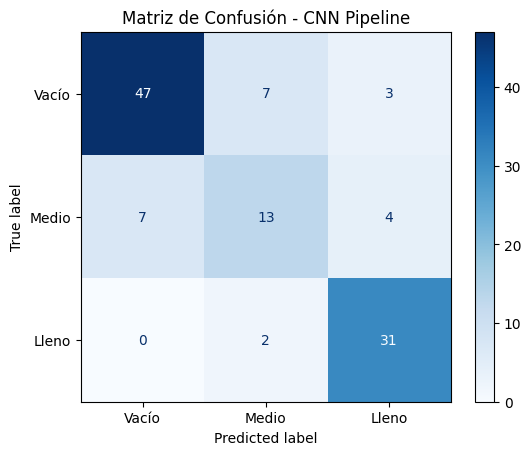

In [ ]:
print("--- ENTRENAMIENTO: CNN PIPELINE + GUARDADO + MATRIZ ---")

if not os.path.exists(dir_destino):
    print("Extrayendo imágenes...")
    with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
        zip_ref.extractall(dir_destino)

df = pd.read_csv(ruta_csv)
carpeta_original_paso2 = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/dataset_imagenes_yolo'
df['ruta_local'] = df['ruta_imagen'].str.replace(carpeta_original_paso2, dir_destino)

# Limpieza y verificación
df = df.dropna(subset=['TARGET_Aforo_Visual'])
df['TARGET_Aforo_Visual'] = df['TARGET_Aforo_Visual'].astype(int)
df = df[df['ruta_local'].apply(os.path.exists)]

# 2. PARTICIÓN 70/20/10
train_df, test_val_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['TARGET_Aforo_Visual'])
val_df, test_df = train_test_split(test_val_df, test_size=0.33, random_state=42, stratify=test_val_df['TARGET_Aforo_Visual'])

# 3. GENERADORES (Sin rescale manual, lo hará el modelo)
datagen = tf.keras.preprocessing.image.ImageDataGenerator()

train_gen = datagen.flow_from_dataframe(train_df, x_col='ruta_local', y_col='TARGET_Aforo_Visual',
                                        target_size=(150, 150), class_mode='raw', batch_size=32)
val_gen = datagen.flow_from_dataframe(val_df, x_col='ruta_local', y_col='TARGET_Aforo_Visual',
                                      target_size=(150, 150), class_mode='raw', batch_size=32)

# 4. ARQUITECTURA DEL PIPELINE CNN
# Incluimos el escalado como la primera capa del modelo
model_cnn_pipeline = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Rescaling(1./255), # Este es el "escalador" dentro del pipeline
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_cnn_pipeline.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 5. ENTRENAMIENTO
print("\nIniciando entrenamiento...")
history = model_cnn_pipeline.fit(train_gen, validation_data=val_gen, epochs=10)

# 6. GUARDAR EL MODELO COMPLETO
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
os.makedirs(ruta_resultados, exist_ok=True)
ruta_archivo_cnn = os.path.join(ruta_resultados, 'modelo_cnn.keras')

model_cnn_pipeline.save(ruta_archivo_cnn)
print(f"\n✅ Modelo CNN guardado con éxito en: {ruta_archivo_cnn}")

# 7. EVALUACIÓN FINAL CON TEST (10%)
test_images = []
for r in test_df['ruta_local']:
    img = tf.keras.utils.load_img(r, target_size=(150, 150))
    test_images.append(tf.keras.utils.img_to_array(img)) # Enviamos píxeles sin escalar (el modelo escala solo)

y_pred = np.argmax(model_cnn_pipeline.predict(np.array(test_images)), axis=1)
y_true = test_df['TARGET_Aforo_Visual'].values

print("\n--- INFORME DE CLASIFICACIÓN ---")
target_names = ['Vacío', 'Medio', 'Lleno']
print(classification_report(y_true, y_pred, target_names=target_names))

# 8. MATRIZ DE CONFUSIÓN
print("\nGenerando Matriz de Confusión...")
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=target_names, cmap='Blues')
plt.title("Matriz de Confusión - CNN Pipeline")
plt.show()

---

### 5. Conclusión

Para entender qué está pasando dentro de la red mientras entrena, es vital comprender cómo los **filtros** extraen información.

**5.1. Diagnóstico Clínico del Modelo (Análisis de la Salida)**

Nuestra red neuronal ha sacado a la luz un fenómeno clásico del *Deep Learning* que encaja perfectamente en el **Punto 8 de tu temario (Overfitting & Underfitting)**.

* **El fantasma del Overfitting:** Fíjemonos en la Época 10\. nuestra precisión en entrenamiento (accuracy) es casi perfecta (**0.97**), pero nuestra precisión en validación se ha estancado en **0.78** y la val\_loss (el error) empezó a subir a partir de la Época 4\. Esto significa que a partir de la cuarta pasada, la red dejó de aprender conceptos generales y empezó a "memorizar" las fotos concretas de entrenamiento.  
* **El problema de la clase "Medio":** Si miramos el *F1-score*, la red distingue bien cuando el bus está **Vacío (0.85)** y cuando está **Lleno (0.88)**. Pero colapsa totalmente en la clase **Medio (0.52)**. ¿Por qué? Por la física de las cámaras. Visualmente, diferenciar a 15 personas (Medio) de 25 personas (Lleno) en un pasillo estrecho genera muchísimas oclusiones (unas cabezas tapan a otras). La cámara duda.

**5.2. Comparativa: Sensores (Tabular) vs Visión (CNN)**

Si comparamos este resultado con nuestro ganador anterior (el Random Forest):

* **Motor de Sensores (CO2, Temp):** 99% de precisión.  
* **Motor de Visión (Cámaras):** 79% de precisión.

¿Significa esto que la cámara no sirve? **Absolutamente no.** Significa que la visión artificial sufre de "ilusiones ópticas" (oclusiones, sombras), mientras que la química del aire (CO2) no miente. Sin embargo, ¿qué pasaría si alguien abre una ventanilla? El CO2 caería en picado engañando a los sensores, pero la cámara seguiría viendo el bus lleno.

¡Aquí es donde entra la magia del ruteo dinámico real\!

**5.3. El Paso Final: Fusión Multimodal (Híbrido)**

En los sistemas de IA de la industria real (como los coches autónomos de Tesla), nunca se confía en un solo sensor. Se utiliza un **Ensemble (Fusión)**. Nuestro sistema central no tomará la decisión solo con el CSV o solo con la foto, sino combinando las probabilidades de ambos.